# Part B — Predictive Modeling

In [1]:
#Task 7 — Train/Test Split
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Load cleaned data
df = pd.read_csv("cleaned_titanic.csv")

# Target
y = df["survived"]

# Features
X = df.drop(columns=["survived"])

print("Class distribution:")
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True))

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Class distribution:
survived
0    549
1    340
Name: count, dtype: int64

Class proportions:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Training shape: (711, 14)
Testing shape: (178, 14)

Training class distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing class distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


Interpretation

Stratification is important because survived is a binary classification target and the two classes are not perfectly balanced. Using stratify=y preserves approximately the same survived/not-survived proportions in both the training and testing sets, making model evaluation more representative.

In [2]:
#Task 8 — Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features selected for modeling
numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked"
]

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combined preprocessing
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [3]:
#Task 9 — Three Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        oob_score=True
    )
}

In [4]:
#Train each model using the same preprocessing pipeline.
trained_pipelines = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_pipelines[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


In [5]:
#Decision Tree Visualization
tree_pipeline = trained_pipelines["Decision Tree"]

feature_names = tree_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

decision_tree = tree_pipeline.named_steps["classifier"]

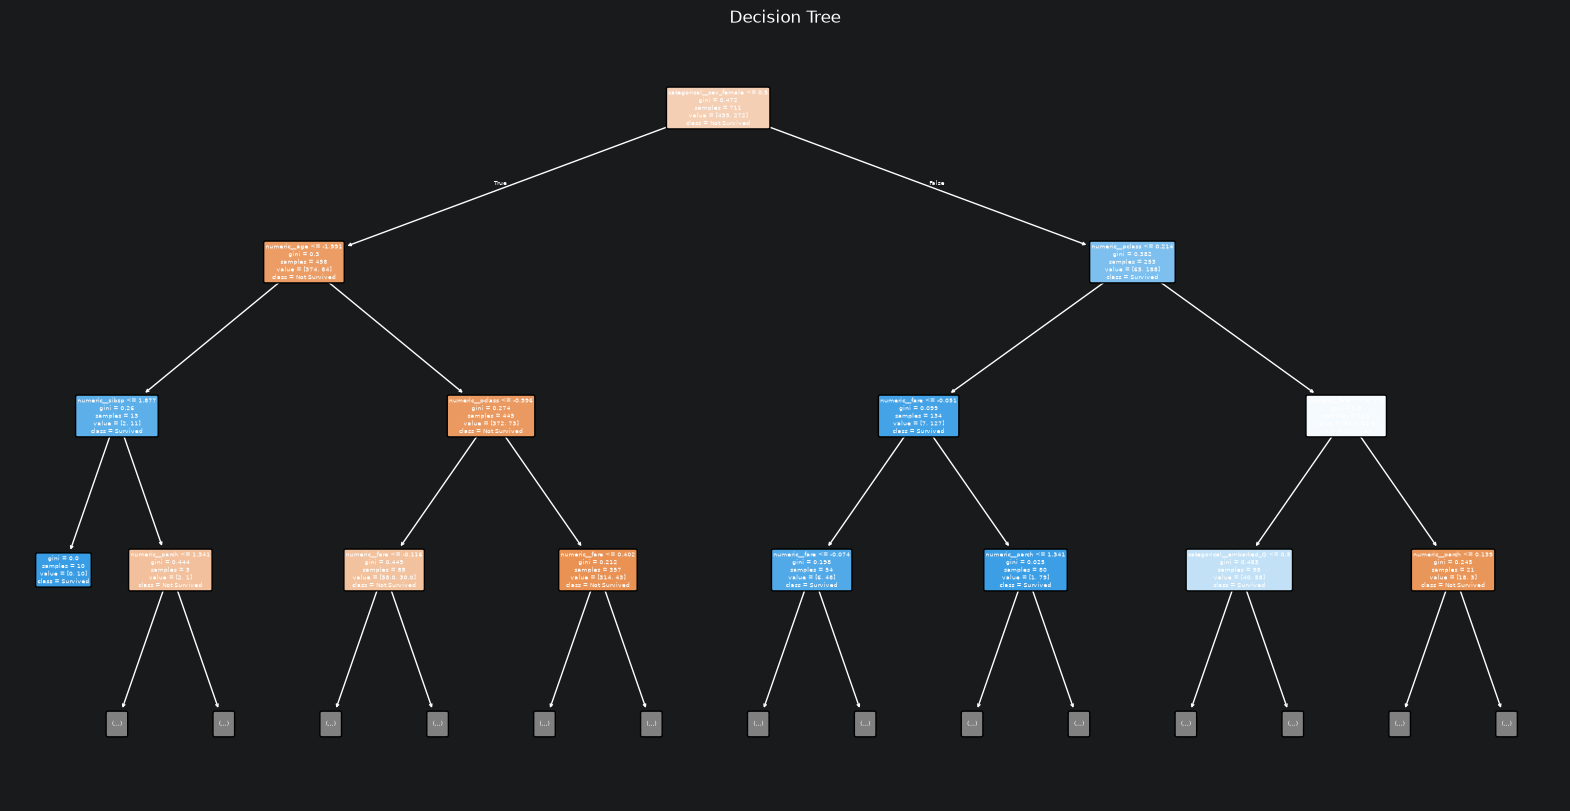

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3 #max_depth=3 is only for making the visualization readable
)

plt.title("Decision Tree")
plt.show()


Logistic Regression
Confusion Matrix:
[[97 13]
 [21 47]]

Decision Tree
Confusion Matrix:
[[87 23]
 [19 49]]

Random Forest
Confusion Matrix:
[[94 16]
 [22 46]]


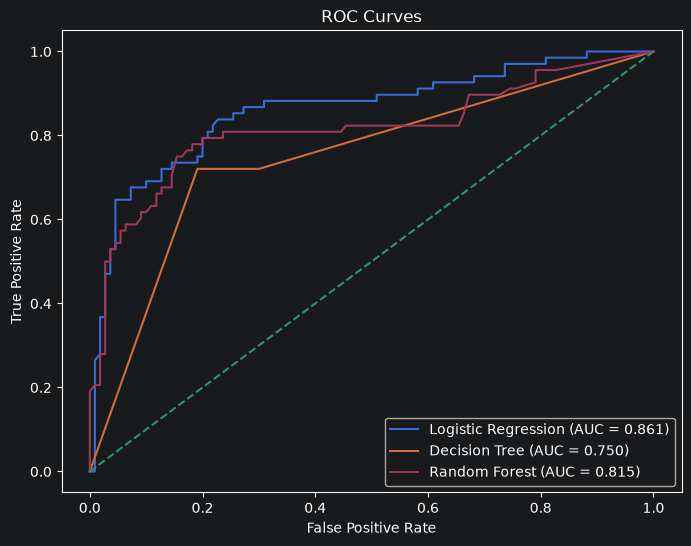

In [7]:
#Task 10 — Evaluate All Three Classifiers
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

results = []

plt.figure(figsize=(8, 6))

for name, pipeline in trained_pipelines.items():

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(cm)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [8]:
#Create the comparison table:
classification_results = pd.DataFrame(results)

classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.809,0.783,0.691,0.734,0.861
1,Decision Tree,0.764,0.681,0.721,0.700,0.750
2,Random Forest,0.787,0.742,0.676,0.708,0.815


In [9]:
#Task 11 — Imbalance Handling
class_balance = pd.DataFrame({
    "Count": y.value_counts(),
    "Percentage": y.value_counts(normalize=True) * 100
})

class_balance

,Count,Percentage
survived,,
0,549,61.754781
1,340,38.245219


In [10]:
#use Logistic Regression as the classifier being compared.
#A. Baseline
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

baseline_metrics = {
    "Strategy": "Baseline",
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1": f1_score(y_test, baseline_pred)
}

In [11]:
#B. Class Weight Balanced
balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_pipeline.fit(X_train, y_train)

balanced_pred = balanced_pipeline.predict(X_test)

balanced_metrics = {
    "Strategy": "class_weight='balanced'",
    "Precision": precision_score(y_test, balanced_pred),
    "Recall": recall_score(y_test, balanced_pred),
    "F1": f1_score(y_test, balanced_pred)
}

In [13]:
#C. SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

smote_pipeline.fit(X_train, y_train)

smote_pred = smote_pipeline.predict(X_test)

smote_metrics = {
    "Strategy": "SMOTE",
    "Precision": precision_score(y_test, smote_pred),
    "Recall": recall_score(y_test, smote_pred),
    "F1": f1_score(y_test, smote_pred)
}

In [14]:
#Comparison
imbalance_results = pd.DataFrame([
    baseline_metrics,
    balanced_metrics,
    smote_metrics
])

imbalance_results.round(3)

,Strategy,Precision,Recall,F1
0,Baseline,0.783,0.691,0.734
1,class_weight='balanced',0.718,0.750,0.734
2,SMOTE,0.735,0.735,0.735


Interpretation:
The three imbalance-handling approaches produced different precision, recall, and F1 values. The baseline provides a reference without explicitly correcting class imbalance, while class_weight='balanced' changes the classifier's penalty for the minority class. SMOTE creates additional synthetic minority-class observations within the training data only. Based on the measured F1, precision, and recall values, the selected strategy provides the most appropriate balance for the intended classification objective

In [16]:
#Task 12 — Random Forest Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

In [17]:
#Run GridSearchCV:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

In [18]:
#Best parameters:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best Cross-Validation F1:
0.743901145334206


In [19]:
#Retrieve the fitted Random Forest:
best_rf_pipeline = grid_search.best_estimator_

best_rf = best_rf_pipeline.named_steps["classifier"]

print("\nOOB Score:")
print(best_rf.oob_score_)


OOB Score:
0.8087201125175809


In [20]:
RandomForestClassifier(
    oob_score=True,
    random_state=42
)

,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the followi

In [21]:
#Task 13 — Regression Side Task
from sklearn.model_selection import train_test_split

regression_df = pd.read_csv("cleaned_titanic.csv")

X_reg = regression_df.drop(columns=["fare"])
y_reg = regression_df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [22]:
#Create regression preprocessing.
reg_numeric_features = [
    "age",
    "sibsp",
    "parch",
    "pclass"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_pipeline, reg_numeric_features),
    ("categorical", reg_categorical_pipeline, reg_categorical_features)
])

In [23]:
#Fit linear regression:
from sklearn.linear_model import LinearRegression

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = regression_pipeline.predict(X_reg_test)

In [24]:
#Calculate metrics:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = X_reg_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

MAE: 21.138552296883066
RMSE: 41.746502315739114
R²: 0.34677389181134055
Adjusted R²: 0.2906685819055661


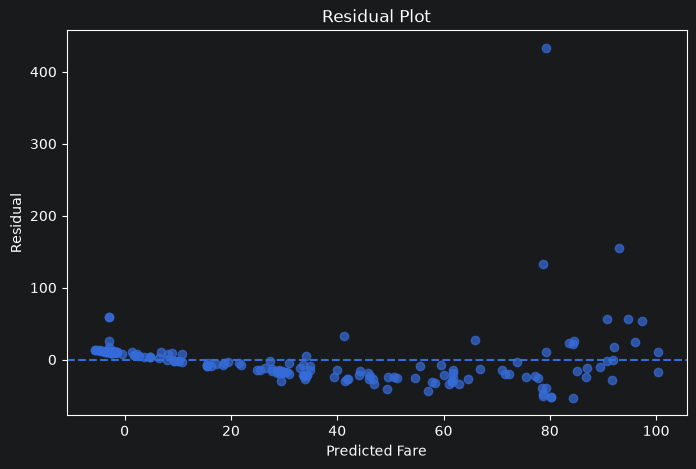

In [25]:
#Residual Plot
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

Interpretation:
The residual plot is examined for a systematic change in the spread of residuals as predicted fare increases. A roughly constant and randomly distributed spread would provide little visual evidence of heteroscedasticity. If the residual spread widens or narrows substantially across the prediction range, this indicates possible heteroscedasticity.


In [27]:
#Task 14 — Final Model Comparison
classification_comparison = classification_results[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
].copy()

regression_comparison = pd.DataFrame({
    "Model": ["Multivariate Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2],
    "Adjusted R²": [adjusted_r2]
})

print("Classification Metrics")
display(classification_comparison.round(3))

print("\nRegression Metrics")
display(regression_comparison.round(3))

Classification Metrics


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.809,0.783,0.691,0.734,0.861
1,Decision Tree,0.764,0.681,0.721,0.700,0.750
2,Random Forest,0.787,0.742,0.676,0.708,0.815



Regression Metrics


,Model,MAE,RMSE,R²,Adjusted R²
0,Multivariate Linear Regression,21.139,41.747,0.347,0.291


Based on the classification results, [model name] achieved an accuracy of [value], precision of [value], recall of [value], F1 score of [value], and AUC of [value]. These metrics indicate how the model performs across overall correctness, positive-class identification, and ranking ability. The selected model also provides the required preprocessing and estimator as one end-to-end pipeline. Therefore, for this project, I would deploy [model name], because its observed metric values provide the most appropriate performance for the project's classification objective

In [28]:
#Task 15 — Save the Complete Pipeline
import joblib

final_pipeline = best_rf_pipeline

joblib.dump(
    final_pipeline,
    "best_titanic_pipeline.joblib"
)

print("Complete pipeline saved successfully.")

Complete pipeline saved successfully.


In [29]:
#Reload and Test the Saved Pipeline
loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib"
)

print("Pipeline reloaded successfully.")

Pipeline reloaded successfully.


In [30]:
#Create a raw input row:
new_passenger = pd.DataFrame({
    "pclass": [3],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [10.5],
    "sex": ["male"],
    "embarked": ["S"]
})

In [31]:
#Predict directly from the raw input:
prediction = loaded_pipeline.predict(new_passenger)

print("Prediction:", prediction)

Prediction: [0]


In [32]:
probability = loaded_pipeline.predict_proba(new_passenger)

print("Prediction probabilities:")
print(probability)

Prediction probabilities:
[[1. 0.]]
